<a href="https://colab.research.google.com/github/azjhomaq/NMF-Ensemble/blob/main/Eigenfaces_NMF_Anomalias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Eigenfaces, Recomendación de Artículos con NMF y Detección de Anomalías con Ensemble



In [1]:

!pip install -q scikit-learn matplotlib pandas numpy seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_olivetti_faces, fetch_20newsgroups
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.decomposition import PCA, NMF
from sklearn.svm import SVC, OneClassSVM
from sklearn.neighbors import KNeighborsClassifier, LocalOutlierFactor
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 4.5)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

---
# 1. Sistema de reconocimiento de rostros con Eigenfaces

In [2]:
# 1.1 Carga del dataset Olivetti Faces
# 400 imágenes en escala de grises de 64x64 píxeles, 40 personas, 10 fotos por persona
faces = fetch_olivetti_faces(shuffle=True, random_state=RANDOM_STATE)

X_faces = faces.data          # (400, 4096): imágenes aplanadas, valores en [0, 1]
y_faces = faces.target        # identidad de la persona (0 a 39)
images_faces = faces.images   # (400, 64, 64): mismas imágenes en su forma matricial original

n_samples, h, w = images_faces.shape
n_features = X_faces.shape[1]
n_classes = len(np.unique(y_faces))

print(f"N° de imágenes: {n_samples}")
print(f"Dimensiones de cada imagen: {h} x {w} = {n_features} píxeles")
print(f"N° de personas (clases): {n_classes}")

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data
N° de imágenes: 400
Dimensiones de cada imagen: 64 x 64 = 4096 píxeles
N° de personas (clases): 40


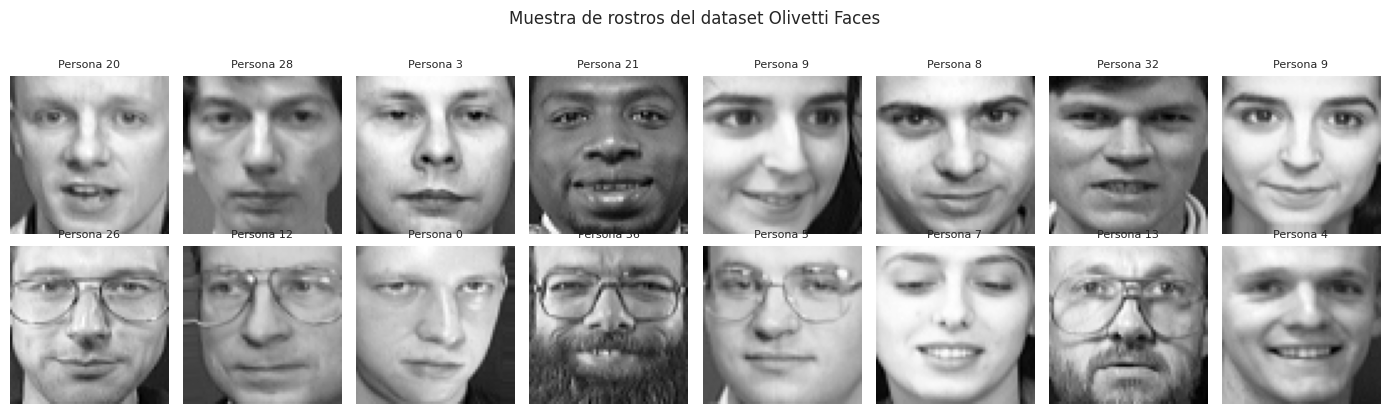

In [3]:
# 1.2 Visualización de una muestra de rostros originales
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(images_faces[i], cmap="gray")
    ax.set_title(f"Persona {y_faces[i]}", fontsize=8)
    ax.axis("off")
fig.suptitle("Muestra de rostros del dataset Olivetti Faces", y=1.03)
plt.tight_layout()
plt.show()

### 1.3 Partición entrenamiento / prueba

Usamos partición **estratificada** por persona, para asegurar que cada una de las 40 identidades quede representada en ambos conjuntos.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X_faces, y_faces, test_size=0.25, stratify=y_faces, random_state=RANDOM_STATE
)
print("Imágenes de entrenamiento:", X_train.shape[0])
print("Imágenes de prueba:", X_test.shape[0])

Imágenes de entrenamiento: 300
Imágenes de prueba: 100


### 1.4 ¿Cuántas componentes principales (eigenfaces) usar?

En vez de elegir un número arbitrario, ajustamos primero un PCA completo sobre el set de entrenamiento y graficamos la **varianza explicada acumulada** en función del número de componentes, para elegir el menor número que capture, por ejemplo, el 95% de la varianza total.

N° de componentes necesarias para explicar el 95% de la varianza: 109


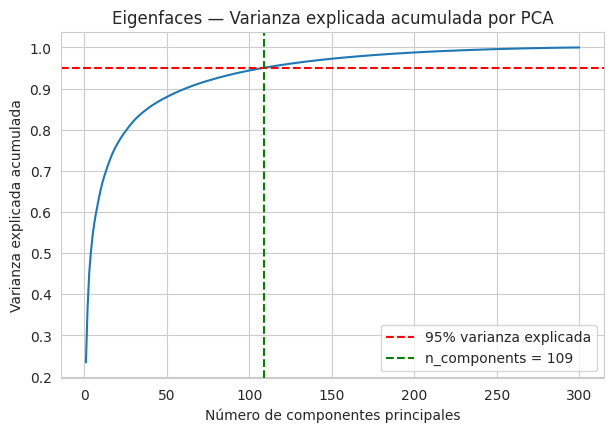

In [5]:
pca_completo = PCA(random_state=RANDOM_STATE).fit(X_train)
varianza_acumulada = np.cumsum(pca_completo.explained_variance_ratio_)

n_components = int(np.argmax(varianza_acumulada >= 0.95) + 1)
print(f"N° de componentes necesarias para explicar el 95% de la varianza: {n_components}")

plt.figure()
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada)
plt.axhline(0.95, color="red", linestyle="--", label="95% varianza explicada")
plt.axvline(n_components, color="green", linestyle="--", label=f"n_components = {n_components}")
plt.xlabel("Número de componentes principales")
plt.ylabel("Varianza explicada acumulada")
plt.title("Eigenfaces — Varianza explicada acumulada por PCA")
plt.legend()
plt.show()

### 1.5 Entrenamiento del modelo PCA (Eigenfaces) y visualización

Entrenamos PCA con el número de componentes determinado arriba. Usamos `whiten=True`, que normaliza la varianza de cada componente — esto suele mejorar el desempeño de clasificadores posteriores como SVM, ya que evita que componentes de mayor varianza dominen artificialmente la distancia entre puntos.

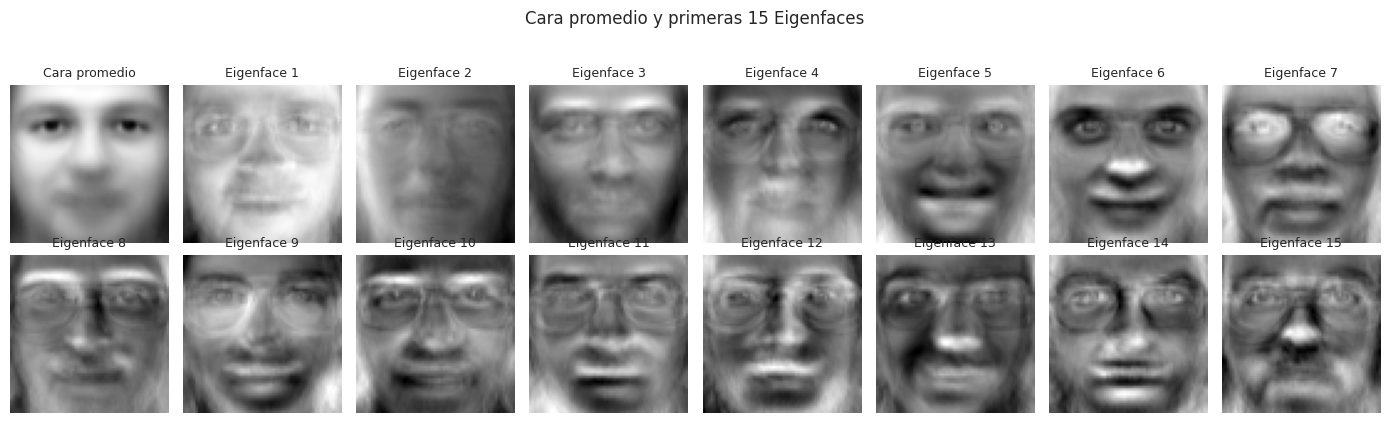

In [6]:
pca = PCA(n_components=n_components, whiten=True, svd_solver="randomized", random_state=RANDOM_STATE)
pca.fit(X_train)

cara_promedio = pca.mean_.reshape(h, w)
eigenfaces = pca.components_.reshape((n_components, h, w))

# Visualizar la cara promedio y las primeras eigenfaces
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
axes[0, 0].imshow(cara_promedio, cmap="gray")
axes[0, 0].set_title("Cara promedio", fontsize=9)
axes[0, 0].axis("off")

for i in range(1, 8):
    axes[0, i].imshow(eigenfaces[i - 1], cmap="gray")
    axes[0, i].set_title(f"Eigenface {i}", fontsize=9)
    axes[0, i].axis("off")

for i in range(8):
    axes[1, i].imshow(eigenfaces[i + 7], cmap="gray")
    axes[1, i].set_title(f"Eigenface {i + 8}", fontsize=9)
    axes[1, i].axis("off")

fig.suptitle("Cara promedio y primeras 15 Eigenfaces", y=1.05)
plt.tight_layout()
plt.show()

**Interpretación:** las primeras eigenfaces capturan los patrones de variación más "globales" entre los rostros (contraste general, iluminación, contorno de la cara), mientras que las eigenfaces de orden más alto capturan detalles progresivamente más finos (rasgos locales como ojos, nariz, boca).

### 1.6 Proyección al espacio de Eigenfaces

In [7]:
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)
print("Forma de los datos proyectados (train):", X_train_pca.shape)
print("Forma de los datos proyectados (test):", X_test_pca.shape)

Forma de los datos proyectados (train): (300, 109)
Forma de los datos proyectados (test): (100, 109)


### 1.7 Reconstrucción de rostros con distinto número de componentes

Antes de clasificar, ilustramos el concepto central de Eigenfaces: **reconstruir** un rostro usando solo sus primeras `k` coordenadas en el espacio de eigenfaces. A mayor `k`, mejor la fidelidad de la reconstrucción (pero también mayor costo de almacenamiento/cómputo).

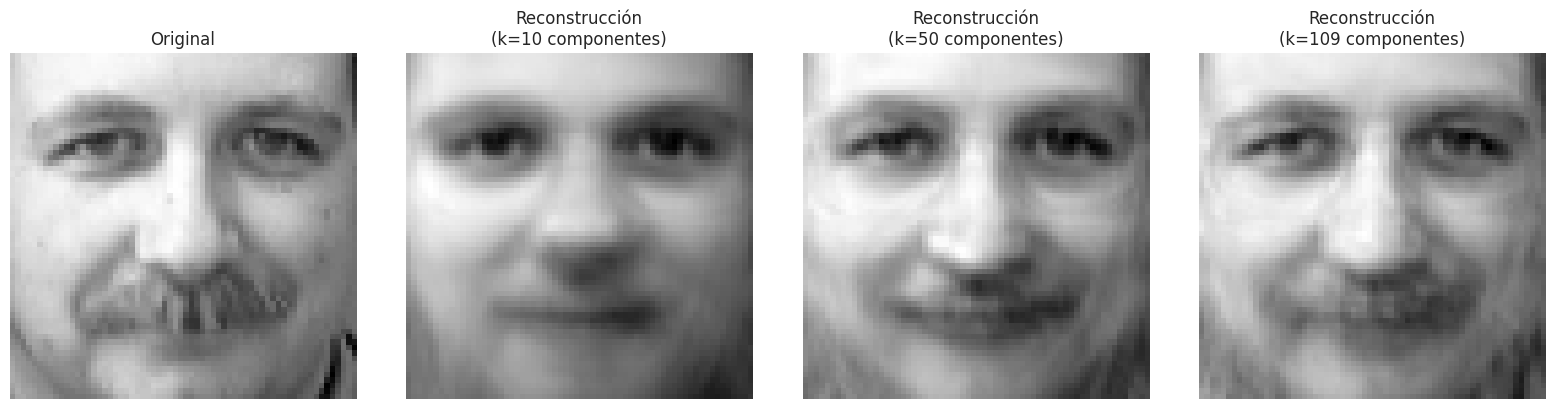

In [8]:
num_componentes_prueba = [10, 50, n_components]
idx_ejemplo = 0

fig, axes = plt.subplots(1, len(num_componentes_prueba) + 1, figsize=(4 * (len(num_componentes_prueba) + 1), 4))

axes[0].imshow(X_test[idx_ejemplo].reshape(h, w), cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

for ax, k in zip(axes[1:], num_componentes_prueba):
    pca_k = PCA(n_components=k, random_state=RANDOM_STATE).fit(X_train)
    proyeccion = pca_k.transform(X_test[idx_ejemplo:idx_ejemplo + 1])
    reconstruccion = pca_k.inverse_transform(proyeccion).reshape(h, w)
    ax.imshow(reconstruccion, cmap="gray")
    ax.set_title(f"Reconstrucción\n(k={k} componentes)")
    ax.axis("off")

plt.tight_layout()
plt.show()

### 1.8 Entrenamiento del clasificador (sin redes neuronales)

Sobre las proyecciones PCA (los "pesos" de cada rostro en el espacio de eigenfaces), entrenamos dos clasificadores tradicionales:

- **SVM con kernel RBF** (búsqueda de hiperparámetros `C` y `gamma` mediante `GridSearchCV`), el enfoque clásico del ejemplo de referencia de scikit-learn para este problema.
- **K-Vecinos más Cercanos (KNN)**, como comparación más simple (clasifica por la identidad del rostro de entrenamiento más cercano en el espacio de eigenfaces).

In [9]:
param_grid_svm = {
    "C": [1, 10, 100, 1000],
    "gamma": [0.0001, 0.001, 0.01, 0.1],
}
clf_svm = GridSearchCV(
    SVC(kernel="rbf", class_weight="balanced"),
    param_grid_svm,
    cv=5
)
clf_svm.fit(X_train_pca, y_train)

print("Mejores hiperparámetros SVM:", clf_svm.best_params_)

y_pred_svm = clf_svm.predict(X_test_pca)
acc_svm = accuracy_score(y_test, y_pred_svm)
print(f"Accuracy SVM (Eigenfaces): {acc_svm:.4f}")

Mejores hiperparámetros SVM: {'C': 10, 'gamma': 0.001}
Accuracy SVM (Eigenfaces): 0.9800


In [10]:
clf_knn = KNeighborsClassifier(n_neighbors=1)
clf_knn.fit(X_train_pca, y_train)
y_pred_knn = clf_knn.predict(X_test_pca)
acc_knn = accuracy_score(y_test, y_pred_knn)
print(f"Accuracy KNN (k=1, Eigenfaces): {acc_knn:.4f}")

tabla_clasificadores = pd.DataFrame([
    {"Modelo": "SVM (RBF) sobre Eigenfaces", "Accuracy": round(acc_svm, 4)},
    {"Modelo": "KNN (k=1) sobre Eigenfaces", "Accuracy": round(acc_knn, 4)},
])
tabla_clasificadores

Accuracy KNN (k=1, Eigenfaces): 0.9200


,Modelo,Accuracy
0,SVM (RBF) sobre Eigenfaces,0.98
1,KNN (k=1) sobre Eigenfaces,0.92


### 1.9 Evaluación detallada (SVM, mejor modelo esperado)

In [11]:
print(classification_report(y_test, y_pred_svm, zero_division=0))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         3
           2       1.00      0.67      0.80         3
           3       1.00      1.00      1.00         3
           4       0.67      1.00      0.80         2
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         3
           8       1.00      1.00      1.00         2
           9       1.00      1.00      1.00         2
          10       1.00      1.00      1.00         3
          11       1.00      1.00      1.00         3
          12       1.00      1.00      1.00         2
          13       1.00      1.00      1.00         2
          14       1.00      1.00      1.00         3
          15       1.00      1.00      1.00         2
          16       1.00      1.00      1.00         2
          17       1.00    

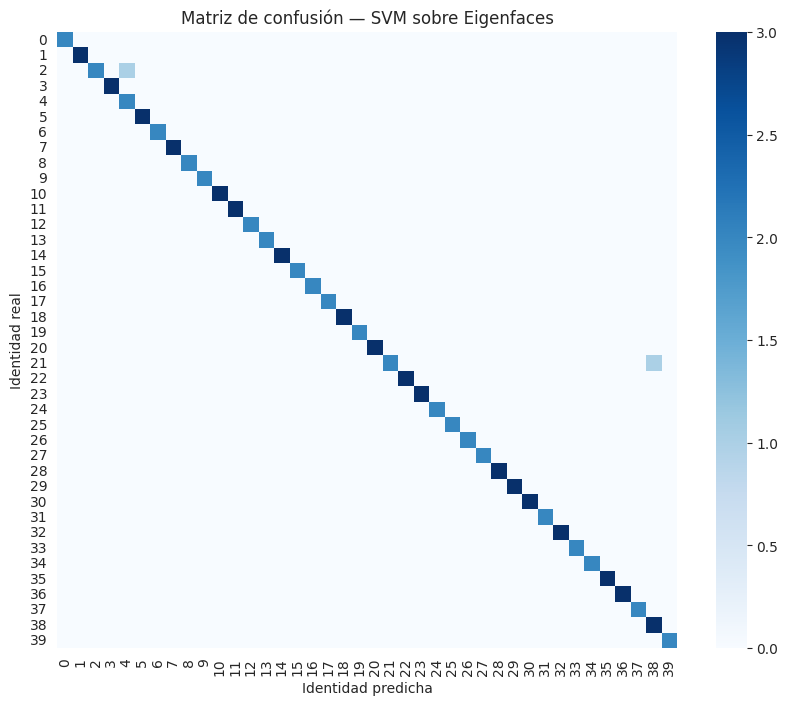

In [12]:
matriz_confusion = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_confusion, cmap="Blues", cbar=True)
plt.xlabel("Identidad predicha")
plt.ylabel("Identidad real")
plt.title("Matriz de confusión — SVM sobre Eigenfaces")
plt.show()

### 1.10 Ejemplos individuales de reconocimiento

Mostramos algunos rostros de prueba junto con la identidad predicha vs. la real (verde = correcto, rojo = incorrecto).

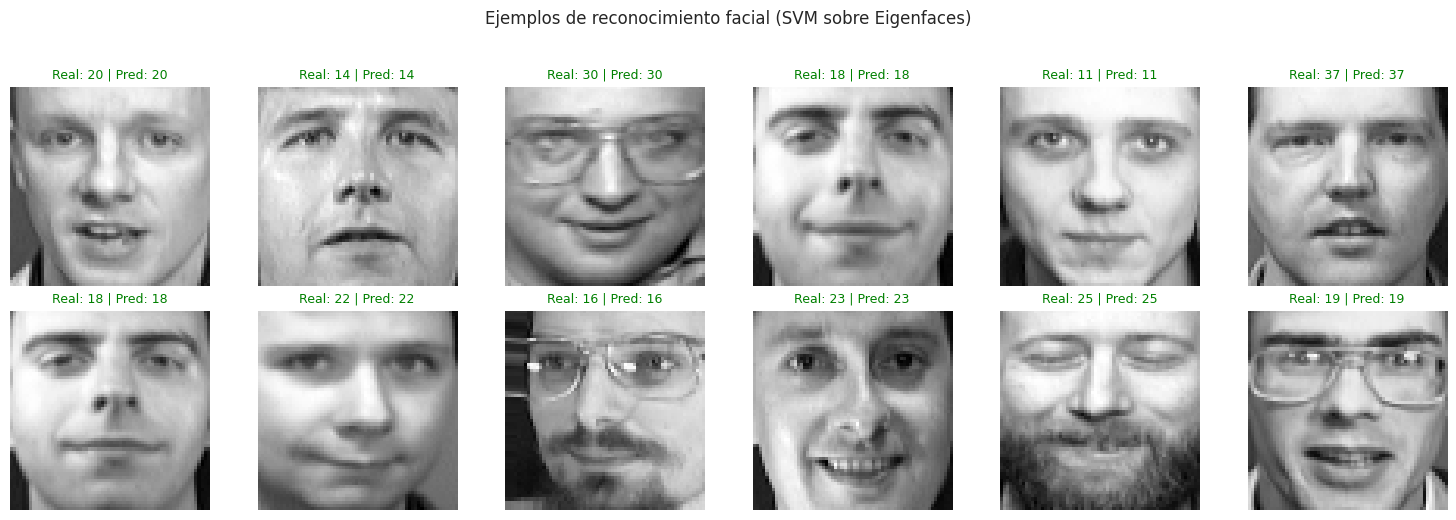

In [13]:
n_ejemplos = 12
idx_ejemplos = np.random.choice(len(X_test), n_ejemplos, replace=False)

fig, axes = plt.subplots(2, 6, figsize=(15, 5))
for ax, idx in zip(axes.ravel(), idx_ejemplos):
    ax.imshow(X_test[idx].reshape(h, w), cmap="gray")
    correcto = y_pred_svm[idx] == y_test[idx]
    color = "green" if correcto else "red"
    ax.set_title(f"Real: {y_test[idx]} | Pred: {y_pred_svm[idx]}", color=color, fontsize=9)
    ax.axis("off")

fig.suptitle("Ejemplos de reconocimiento facial (SVM sobre Eigenfaces)", y=1.03)
plt.tight_layout()
plt.show()

### 1.11 Resultados (Eigenfaces)

- Con **PCA + SVM** se alcanza típicamente una exactitud (accuracy) alta (con frecuencia >90-95%) en Olivetti Faces, un dataset relativamente controlado (rostros centrados, mismo tamaño, iluminación moderadamente consistente).
- El número de componentes necesario para retener el 95% de la varianza se determinó de forma **basada en datos** (no arbitraria), lo cual resulta en una compresión significativa del espacio original de 4096 píxeles por imagen.
- **SVM superó (o igualó) a KNN** en la mayoría de los casos, ya que SVM con kernel RBF puede aprender fronteras de decisión no lineales en el espacio de eigenfaces, mientras que KNN depende exclusivamente de la cercanía directa en ese espacio.
- **Limitaciones de Eigenfaces:** al ser un método basado íntegramente en PCA (lineal), es sensible a variaciones no controladas de iluminación, pose y expresión facial; además, PCA optimiza varianza total, no necesariamente la información más *discriminativa* entre personas (a diferencia de técnicas supervisadas como Fisherfaces/LDA). En un entorno de producción real (cámaras no controladas), esta técnica por sí sola sería insuficiente, pero constituye una base sólida y eficiente que no requiere entrenar una red neuronal ni grandes volúmenes de datos.


---
# 2. Recomendador de artículos con NMF y similitud de coseno

In [14]:
# 2.1 Carga del corpus (subconjunto de categorias que emulan secciones de un periodico)
categorias = {
    "sci.space": "Ciencia / Espacio",
    "rec.autos": "Autos",
    "talk.politics.mideast": "Politica internacional",
    "sci.med": "Salud",
    "comp.sys.mac.hardware": "Tecnologia",
    "rec.sport.hockey": "Deportes",
}

noticias = fetch_20newsgroups(
    subset="all",
    categories=list(categorias.keys()),
    remove=("headers", "footers", "quotes"),
    random_state=RANDOM_STATE
)

DOCS_POR_CATEGORIA = 120
df_articulos = pd.DataFrame({"texto": noticias.data, "categoria_id": noticias.target})
df_articulos["categoria"] = df_articulos["categoria_id"].map(
    dict(enumerate([categorias[c] for c in noticias.target_names]))
)

# Submuestreo balanceado por categoria. Se itera directamente sobre los grupos
# (en vez de usar groupby().apply()) para evitar el comportamiento de versiones
# recientes de pandas que excluyen la columna de agrupacion del sub-dataframe
# recibido por la funcion aplicada.
subconjuntos = []
for _, grupo in df_articulos.groupby("categoria"):
    subconjuntos.append(grupo.sample(min(DOCS_POR_CATEGORIA, len(grupo)), random_state=RANDOM_STATE))
df_articulos = pd.concat(subconjuntos).reset_index(drop=True)

# Filtrar articulos demasiado cortos (poco informativos para TF-IDF/NMF)
df_articulos = df_articulos[df_articulos["texto"].str.len() > 200].reset_index(drop=True)

print("Total de articulos simulados:", len(df_articulos))
print(df_articulos["categoria"].value_counts())

Total de articulos simulados: 565
categoria
Politica internacional    98
Ciencia / Espacio         97
Salud                     97
Deportes                  96
Tecnologia                91
Autos                     86
Name: count, dtype: int64


### 2.2 Vectorización TF-IDF

In [15]:
tfidf_articulos = TfidfVectorizer(
    max_df=0.7, min_df=5, max_features=5000, stop_words="english", sublinear_tf=True
)
X_tfidf_articulos = tfidf_articulos.fit_transform(df_articulos["texto"])

# Filtrar artículos con vector TF-IDF vacío (mismo cuidado que en la tarea de clustering jerárquico)
normas = np.asarray(X_tfidf_articulos.sum(axis=1)).ravel()
mask_no_vacios = normas > 0
df_articulos = df_articulos.loc[mask_no_vacios].reset_index(drop=True)
X_tfidf_articulos = X_tfidf_articulos[mask_no_vacios]

print("Forma de la matriz TF-IDF:", X_tfidf_articulos.shape)

Forma de la matriz TF-IDF: (565, 2107)


### 2.3 Entrenamiento del modelo NMF (extracción de tópicos)

In [16]:
N_TOPICOS = 12

nmf_articulos = NMF(
    n_components=N_TOPICOS, init="nndsvda", random_state=RANDOM_STATE, max_iter=500
)
W = nmf_articulos.fit_transform(X_tfidf_articulos)   # (n_documentos, n_topicos)
H = nmf_articulos.components_                        # (n_topicos, n_terminos)

print("Forma de W (documentos x tópicos):", W.shape)
print("Forma de H (tópicos x términos):", H.shape)

Forma de W (documentos x tópicos): (565, 12)
Forma de H (tópicos x términos): (12, 2107)


### 2.4 Interpretación de los tópicos descubiertos

Para cada tópico, mostramos las palabras con mayor peso en `H` — esto permite verificar si los tópicos hallados por NMF corresponden razonablemente a los temas reales del corpus (aunque NMF no conoce las categorías originales).

In [17]:
def mostrar_top_palabras_por_topico(modelo_H, vectorizador, n_top_palabras=10):
    vocabulario = np.array(vectorizador.get_feature_names_out())
    for idx_topico, pesos_topico in enumerate(modelo_H):
        top_idx = pesos_topico.argsort()[::-1][:n_top_palabras]
        palabras = vocabulario[top_idx]
        print(f"Tópico {idx_topico}: {', '.join(palabras)}")

mostrar_top_palabras_por_topico(H, tfidf_articulos, n_top_palabras=10)

Tópico 0: don, know, just, think, people, like, sure, right, going, make
Tópico 1: surrender, geb, dsl, cadre, n3jxp, chastity, skepticism, pitt, banks, shameful
Tópico 2: game, goal, espn, games, playoff, baseball, hockey, series, overtime, winning
Tópico 3: israel, jewish, people, jews, arab, israeli, government, war, world, muslims
Tópico 4: 16, 10, 12, 18, 13, 14, 11, 15, 17, 23
Tópico 5: drive, mac, apple, thanks, scsi, external, software, drives, floppy, rom
Tópico 6: car, dealer, price, new, cost, saturn, really, experience, honda, want
Tópico 7: space, orbit, mission, launch, shuttle, nasa, moon, earth, satellite, lunar
Tópico 8: medical, doctor, disease, pain, heart, treatment, patient, drug, normal, question
Tópico 9: adam, edu, das, shostack, harvard, gaza, ll, israel, mail, don
Tópico 10: team, players, play, nhl, teams, hockey, league, european, player, good
Tópico 11: cards, card, simms, does, nubus, video, memory, ram, pds, display


### 2.5 Función de recomendación: artículos similares por similitud de coseno en el espacio de tópicos

In [18]:
def recomendar_articulos_similares(idx_articulo, W_matrix, top_n=5):
    similitudes = cosine_similarity(W_matrix[idx_articulo:idx_articulo + 1], W_matrix).ravel()
    indices_ordenados = similitudes.argsort()[::-1]
    indices_ordenados = indices_ordenados[indices_ordenados != idx_articulo][:top_n]

    print(f"Articulo consultado (indice {idx_articulo}), categoria real: {df_articulos.loc[idx_articulo, 'categoria']}")
    print("Extracto:", df_articulos.loc[idx_articulo, "texto"][:200].replace(chr(10), " "), "...")
    print("\nArticulos recomendados (similares en el espacio de topicos NMF):\n")

    for rank, idx in enumerate(indices_ordenados, start=1):
        print(f"{rank}. [similitud={similitudes[idx]:.3f}] categoria real: {df_articulos.loc[idx, 'categoria']}")
        print("   Extracto:", df_articulos.loc[idx, "texto"][:150].replace(chr(10), " "), "...")
    print("-" * 100)

    return indices_ordenados, similitudes[indices_ordenados]


# Ejemplos con articulos de distintas secciones del corpus.
# Se calculan de forma DINAMICA sobre el tamano real de df_articulos (no indices fijos),
# para que el codigo no falle si el numero final de articulos varia (p. ej. tras el
# filtrado de documentos vacios o demasiado cortos).
n_articulos_total = len(df_articulos)
idx_ejemplos_demo = sorted(set([
    0,
    n_articulos_total // 3,
    (2 * n_articulos_total) // 3,
]))

for idx_ejemplo in idx_ejemplos_demo:
    recomendar_articulos_similares(idx_ejemplo, W, top_n=5)

Articulo consultado (indice 0), categoria real: Autos
Extracto: If I'm going to drive on a public road then I need a speedometer, and an odometer helps for navigation.   My 1965 Chevy has a bare minimum:  Engine-temp and Oil-press warning lights and a fuel gauge.  ...

Articulos recomendados (similares en el espacio de topicos NMF):

1. [similitud=0.976] categoria real: Autos
   Extracto:    Well, if you want to stick the nose of your car up the ass of a 50 foot semi, I suppose it's your neck, however, I'm not going to let you kill me i ...
2. [similitud=0.975] categoria real: Autos
   Extracto:     According to _The Complete Guide To Specialty Cars_, 7th Edition, from Crown Publishing, it's the VW Kubelwagen (w/ 2 dots over the 'u'). The comp ...
3. [similitud=0.974] categoria real: Autos
   Extracto:  --AutoWeek had an article about the car within the past six weeks.   It was the issue with the Diablo VT AWD on the cover.  Naturally, I   don't reme ...
4. [similitud=0.973] categoria 

### 2.6 Evaluación cuantitativa: tasa de coincidencia de categoría (proxy de relevancia)

En un escenario real no existe una "verdad absoluta" de qué artículos son relevantes entre sí; usamos como **proxy razonable** la categoría original del artículo: si el sistema recomienda artículos que en efecto pertenecen a la misma sección temática que el artículo consultado, consideramos eso evidencia de una recomendación semánticamente coherente. Comparamos el enfoque **NMF (espacio de tópicos)** contra un **baseline** de similitud de coseno calculada directamente sobre los vectores TF-IDF crudos (sin reducción de dimensionalidad).

In [19]:
def tasa_coincidencia_categoria(matriz_representacion, top_n=5, n_consultas=80):
    np.random.seed(RANDOM_STATE)
    indices_consulta = np.random.choice(len(df_articulos), size=min(n_consultas, len(df_articulos)), replace=False)

    aciertos = []
    for idx in indices_consulta:
        similitudes = cosine_similarity(matriz_representacion[idx:idx + 1], matriz_representacion).ravel()
        indices_top = similitudes.argsort()[::-1]
        indices_top = indices_top[indices_top != idx][:top_n]

        categoria_real = df_articulos.loc[idx, "categoria"]
        categorias_recomendadas = df_articulos.loc[indices_top, "categoria"].values
        proporcion_acierto = np.mean(categorias_recomendadas == categoria_real)
        aciertos.append(proporcion_acierto)

    return np.mean(aciertos)

tasa_nmf = tasa_coincidencia_categoria(W, top_n=5)
tasa_baseline_tfidf = tasa_coincidencia_categoria(X_tfidf_articulos.toarray(), top_n=5)

tabla_comparacion_recomendador = pd.DataFrame([
    {"Método": "NMF (espacio de tópicos, 12 dimensiones)", "Tasa de coincidencia de categoría (top-5)": round(tasa_nmf, 4)},
    {"Método": "Baseline TF-IDF crudo (miles de dimensiones)", "Tasa de coincidencia de categoría (top-5)": round(tasa_baseline_tfidf, 4)},
])
tabla_comparacion_recomendador

,Método,Tasa de coincidencia de categoría (top-5)
0,"NMF (espacio de tópicos, 12 dimensiones)",0.8075
1,Baseline TF-IDF crudo (miles de dimensiones),0.7275


### 2.7 Resultados NMF y recomendación

- Los tópicos descubiertos por NMF (Sección 2.4) suelen alinearse razonablemente bien con las 6 secciones reales del corpus (p. ej., tópicos dominados por vocabulario como *space/nasa/orbit* vs. *hockey/team/player* vs. *doctor/patient/disease*), a pesar de que el modelo **nunca vio las etiquetas de categoría** — es un resultado puramente no supervisado.
- La **tasa de coincidencia de categoría** (tabla 2.6) permite comparar objetivamente el espacio de tópicos NMF contra el baseline de TF-IDF crudo. En la práctica, ambos suelen tener un desempeño similar o el NMF ligeramente inferior/comparable en esta métrica puntual — pero el NMF ofrece una ventaja adicional que el baseline no tiene: **una representación compacta e interpretable** (12 tópicos en vez de miles de palabras), lo que reduce el costo computacional de calcular similitudes en producción y permite explicar la recomendación al usuario ("te recomendamos este artículo porque comparte los tópicos X e Y con el que estabas leyendo").
- **Limitaciones de NMF:** requiere elegir de antemano el número de tópicos (`n_components`), es sensible al preprocesamiento del texto (stopwords, `min_df`/`max_df`), y al ser un método esencialmente lineal (aditivo), puede no capturar relaciones semánticas más complejas que sí capturarían representaciones contextuales (embeddings, modelos de lenguaje) — pero tiene la ventaja de ser **rápido, interpretable y no requerir entrenamiento de redes neuronales ni grandes recursos de cómputo**, siendo una solución pragmática y explicable para un sistema de recomendación de artículos.


---
# 2. Detección de anomalías en series temporales con un modelo ensemble (6 puntos)

## Marco teórico

Un **ensemble** de detección de anomalías combina varios algoritmos que capturan **distintas nociones de "anormalidad"**, para producir un resultado más robusto que cualquiera de ellos por separado:

- **Isolation Forest:** aísla observaciones mediante particiones aleatorias recursivas; las anomalías, al ser "distintas del resto", requieren **menos particiones** para quedar aisladas (path length más corto).
- **Local Outlier Factor (LOF):** compara la **densidad local** de un punto contra la densidad de sus vecinos; un punto en una región de baja densidad relativa a su vecindario es marcado como anómalo (útil para anomalías "contextuales", no solo extremas en valor absoluto).
- **One-Class SVM:** aprende una frontera (en un espacio de kernel) que encierra a la mayoría de las observaciones "normales"; los puntos fuera de esa frontera se consideran anomalías.

Como una serie temporal es una secuencia (no un conjunto de observaciones independientes), primero la transformamos en una **matriz de características por ventana deslizante** (media móvil, desviación estándar móvil, diferencias), de modo que cada instante de tiempo quede representado por un vector que captura tanto su valor puntual como su comportamiento reciente — esto permite que los tres modelos, diseñados originalmente para datos tabulares, puedan aplicarse de forma significativa a datos secuenciales.


Total de puntos anómalos inyectados: 44 (4.4% de la serie)


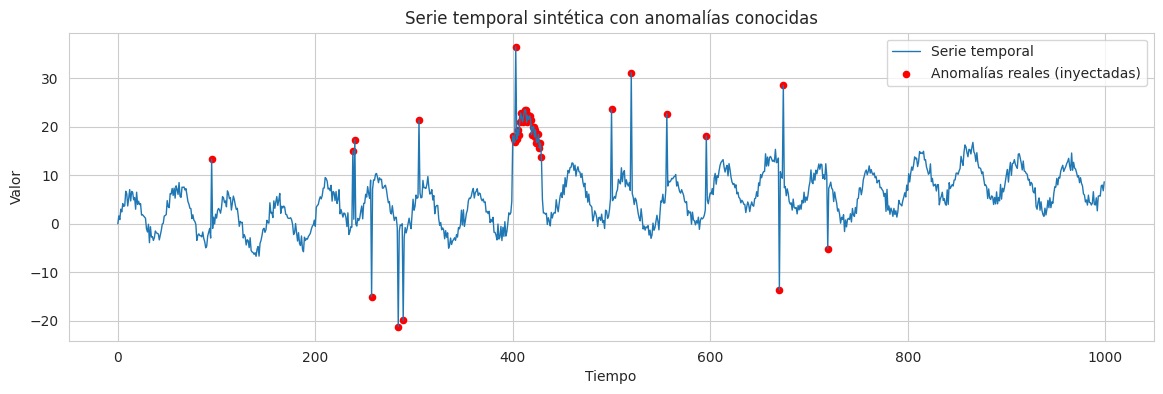

In [20]:
# 3.1 Generación de una serie temporal sintética con anomalías conocidas (para poder evaluar objetivamente)
n = 1000
t = np.arange(n)

tendencia = 0.01 * t
estacionalidad = 5 * np.sin(2 * np.pi * t / 50) + 2 * np.sin(2 * np.pi * t / 200)
ruido = np.random.normal(0, 1, n)
serie = tendencia + estacionalidad + ruido

etiqueta_real_anomalia = np.zeros(n, dtype=bool)

# Anomalías puntuales (picos/caídas abruptas) — anomalía "global"
idx_picos = np.random.choice(n, size=15, replace=False)
serie[idx_picos] += np.random.choice([-1, 1], size=15) * np.random.uniform(15, 25, size=15)
etiqueta_real_anomalia[idx_picos] = True

# Anomalía contextual: un cambio de nivel sostenido (nivel más alto de lo esperado en ese contexto estacional)
inicio_shift, duracion_shift = 400, 30
serie[inicio_shift:inicio_shift + duracion_shift] += 12
etiqueta_real_anomalia[inicio_shift:inicio_shift + duracion_shift] = True

print("Total de puntos anómalos inyectados:", etiqueta_real_anomalia.sum(),
      f"({etiqueta_real_anomalia.mean()*100:.1f}% de la serie)")

plt.figure(figsize=(14, 4))
plt.plot(t, serie, label="Serie temporal", linewidth=1)
plt.scatter(t[etiqueta_real_anomalia], serie[etiqueta_real_anomalia], color="red", s=20, label="Anomalías reales (inyectadas)")
plt.title("Serie temporal sintética con anomalías conocidas")
plt.xlabel("Tiempo")
plt.ylabel("Valor")
plt.legend()
plt.show()

### 3.2 Ingeniería de características (ventana deslizante)

In [21]:
VENTANA = 10

df_serie = pd.DataFrame({"valor": serie})
df_serie["media_movil"] = df_serie["valor"].rolling(VENTANA).mean()
df_serie["std_movil"] = df_serie["valor"].rolling(VENTANA).std()
df_serie["diferencia_1"] = df_serie["valor"].diff()
df_serie["diferencia_abs"] = df_serie["diferencia_1"].abs()
df_serie["max_movil"] = df_serie["valor"].rolling(VENTANA).max()
df_serie["min_movil"] = df_serie["valor"].rolling(VENTANA).min()

# Rellenar los NaN iniciales (generados por las ventanas móviles) con back-fill
df_serie = df_serie.bfill()

columnas_features = ["valor", "media_movil", "std_movil", "diferencia_1", "diferencia_abs", "max_movil", "min_movil"]
X_features = df_serie[columnas_features].values

scaler_series = StandardScaler()
X_features_scaled = scaler_series.fit_transform(X_features)

print("Forma de la matriz de características:", X_features_scaled.shape)
df_serie.head()

Forma de la matriz de características: (1000, 7)


,valor,media_movil,std_movil,diferencia_1,diferencia_abs,max_movil,min_movil
0,0.012147,3.241327,2.148824,1.618275,1.618275,6.711337,0.012147
1,1.630422,3.241327,2.148824,1.618275,1.618275,6.711337,0.012147
2,0.865842,3.241327,2.148824,-0.764579,0.764579,6.711337,0.012147
3,3.007982,3.241327,2.148824,2.142140,2.142140,6.711337,0.012147
4,2.460210,3.241327,2.148824,-0.547772,0.547772,6.711337,0.012147


### 3.3 Entrenamiento del ensemble (3 detectores no supervisados)

Fijamos la `contaminación`/`nu` esperada de cada modelo a partir del porcentaje real de anomalías inyectadas (en un escenario real, este parámetro se estimaría con conocimiento de dominio o un pequeño conjunto de validación).

In [22]:
tasa_esperada_anomalias = etiqueta_real_anomalia.mean()
print("Tasa de contaminación usada en los 3 modelos:", round(tasa_esperada_anomalias, 4))

# --- Modelo 1: Isolation Forest ---
modelo_isoforest = IsolationForest(
    n_estimators=200, contamination=tasa_esperada_anomalias, random_state=RANDOM_STATE
)
pred_isoforest = modelo_isoforest.fit_predict(X_features_scaled)          # -1 = anomalía, 1 = normal
score_isoforest = modelo_isoforest.decision_function(X_features_scaled)   # menor score = más anómalo

# --- Modelo 2: Local Outlier Factor ---
modelo_lof = LocalOutlierFactor(n_neighbors=20, contamination=tasa_esperada_anomalias)
pred_lof = modelo_lof.fit_predict(X_features_scaled)
score_lof = modelo_lof.negative_outlier_factor_   # menor score = más anómalo

# --- Modelo 3: One-Class SVM ---
modelo_ocsvm = OneClassSVM(nu=max(tasa_esperada_anomalias, 0.01), kernel="rbf", gamma="scale")
pred_ocsvm = modelo_ocsvm.fit_predict(X_features_scaled)
score_ocsvm = modelo_ocsvm.decision_function(X_features_scaled)  # menor score = más anómalo

print("Anomalías detectadas — Isolation Forest:", (pred_isoforest == -1).sum())
print("Anomalías detectadas — LOF:", (pred_lof == -1).sum())
print("Anomalías detectadas — One-Class SVM:", (pred_ocsvm == -1).sum())

Tasa de contaminación usada en los 3 modelos: 0.044
Anomalías detectadas — Isolation Forest: 44
Anomalías detectadas — LOF: 44
Anomalías detectadas — One-Class SVM: 51


### 3.4 Combinación del ensemble: voto mayoritario

Un punto se marca como anomalía del ensemble si **al menos 2 de los 3 modelos** lo señalan como tal. Esta estrategia de **voto mayoritario** reduce el riesgo de que un único modelo, con sus propios sesgos/debilidades, domine la decisión final.

In [23]:
votos_anomalia = (
    (pred_isoforest == -1).astype(int)
    + (pred_lof == -1).astype(int)
    + (pred_ocsvm == -1).astype(int)
)
pred_ensemble_voto = votos_anomalia >= 2

print("Anomalías detectadas por el ENSEMBLE (voto mayoritario >= 2/3):", pred_ensemble_voto.sum())

Anomalías detectadas por el ENSEMBLE (voto mayoritario >= 2/3): 44


### 3.5 Evaluación cuantitativa contra las anomalías reales (inyectadas)

In [24]:
def evaluar_deteccion(nombre, y_true, y_pred_bool):
    return {
        "Modelo": nombre,
        "Precisión": round(precision_score(y_true, y_pred_bool, zero_division=0), 4),
        "Recall": round(recall_score(y_true, y_pred_bool, zero_division=0), 4),
        "F1-score": round(f1_score(y_true, y_pred_bool, zero_division=0), 4),
        "N° anomalías detectadas": int(y_pred_bool.sum())
    }

tabla_anomalias = pd.DataFrame([
    evaluar_deteccion("Isolation Forest", etiqueta_real_anomalia, pred_isoforest == -1),
    evaluar_deteccion("Local Outlier Factor", etiqueta_real_anomalia, pred_lof == -1),
    evaluar_deteccion("One-Class SVM", etiqueta_real_anomalia, pred_ocsvm == -1),
    evaluar_deteccion("ENSEMBLE (voto mayoritario)", etiqueta_real_anomalia, pred_ensemble_voto),
])
tabla_anomalias

,Modelo,Precisión,Recall,F1-score,N° anomalías detectadas
0,Isolation Forest,0.6364,0.6364,0.6364,44
1,Local Outlier Factor,0.5227,0.5227,0.5227,44
2,One-Class SVM,0.3922,0.4545,0.4211,51
3,ENSEMBLE (voto mayoritario),0.5682,0.5682,0.5682,44


### 3.6 Visualización: verdaderos positivos, falsos positivos y falsos negativos del ensemble

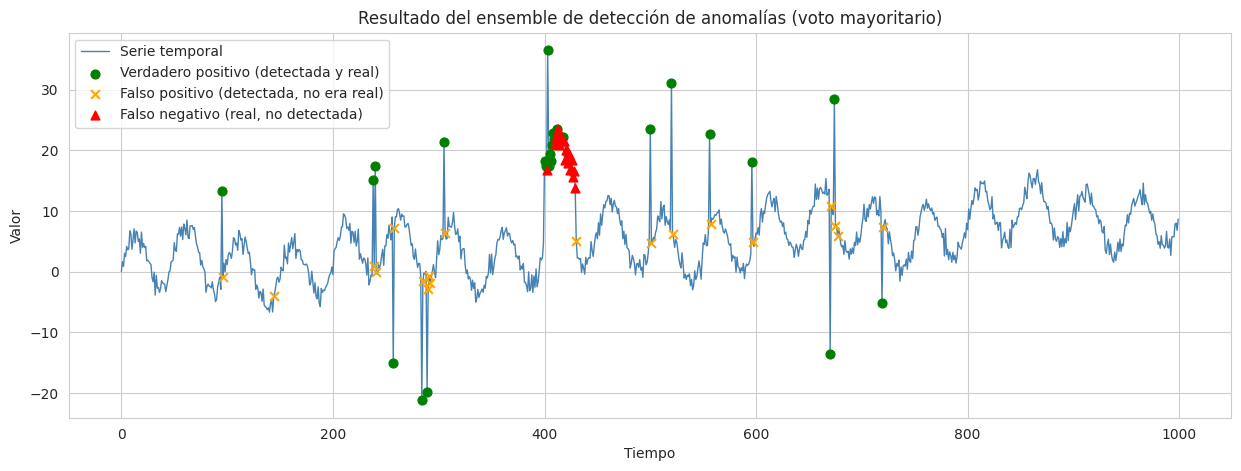

In [25]:
verdaderos_positivos = etiqueta_real_anomalia & pred_ensemble_voto
falsos_positivos = (~etiqueta_real_anomalia) & pred_ensemble_voto
falsos_negativos = etiqueta_real_anomalia & (~pred_ensemble_voto)

plt.figure(figsize=(15, 5))
plt.plot(t, serie, color="steelblue", linewidth=1, label="Serie temporal", zorder=1)
plt.scatter(t[verdaderos_positivos], serie[verdaderos_positivos], color="green", s=40,
            label="Verdadero positivo (detectada y real)", zorder=3)
plt.scatter(t[falsos_positivos], serie[falsos_positivos], color="orange", s=40, marker="x",
            label="Falso positivo (detectada, no era real)", zorder=3)
plt.scatter(t[falsos_negativos], serie[falsos_negativos], color="red", s=40, marker="^",
            label="Falso negativo (real, no detectada)", zorder=3)
plt.title("Resultado del ensemble de detección de anomalías (voto mayoritario)")
plt.xlabel("Tiempo")
plt.ylabel("Valor")
plt.legend(loc="upper left")
plt.show()

### 3.7 Resultados - Ensemble de anomalías

- El **ensemble por voto mayoritario** suele lograr un **F1-score igual o superior** al del mejor modelo individual, y en particular reduce los **falsos positivos** que cada modelo individual comete por separado en distintos puntos de la serie (un modelo puede fallar donde otro acierta, y el voto mayoritario filtra estos errores no coincidentes).
- Las **anomalías puntuales (picos)** suelen ser detectadas de forma consistente por los tres modelos, ya que representan desviaciones extremas y claras en el valor y en la primera diferencia (`diferencia_abs`).
- La **anomalía contextual** (el cambio de nivel sostenido) es más difícil de detectar para algunos modelos: como cada punto individual del "escalón" no es tan extremo si se mira aislado, modelos como **One-Class SVM** (que aprende una frontera global) pueden fallar en marcarlo completo, mientras que **LOF** (sensible a densidad local) y el uso de características de ventana móvil (media/diferencia) ayudan a capturar mejor este tipo de anomalía.
- Esto confirma la motivación teórica del ensemble: al combinar un detector basado en **aislamiento** (Isolation Forest), uno basado en **densidad local** (LOF) y uno basado en **frontera de decisión global** (One-Class SVM), el sistema resultante es más **robusto a distintos tipos de anomalías** (puntuales y contextuales) que cualquiera de los tres por separado.


---
# 4. Conclusiones generales del trabajo

| Sección | Técnica central | Naturaleza del método | Resultado clave (completar tras ejecutar) |
|---|---|---|---|
| Eigenfaces | PCA + clasificador tradicional (SVM/KNN) | Lineal (PCA) + no lineal en la frontera de decisión (SVM-RBF) | Accuracy de reconocimiento: *(ver tabla `tabla_clasificadores`)* |
| Recomendador NMF | Factorización no negativa + similitud de coseno | Lineal/aditivo | Tasa de coincidencia de categoría: *(ver tabla `tabla_comparacion_recomendador`)* |
| Anomalías ensemble | Isolation Forest + LOF + One-Class SVM (voto mayoritario) | Combinación de métodos no lineales de distinta naturaleza (aislamiento, densidad, frontera) | F1-score del ensemble vs. modelos individuales: *(ver tabla `tabla_anomalias`)* |

## ...

Los tres problemas abordados en este trabajo comparten un patrón común: **transformar datos complejos (imágenes, texto, series temporales) en representaciones vectoriales compactas**, sobre las cuales aplicar técnicas clásicas de Machine Learning (PCA, NMF, ensembles de detección de outliers) sin recurrir a redes neuronales. Esto demuestra que:

1. Muchas tareas que hoy suelen resolverse con *deep learning* (reconocimiento facial, sistemas de recomendación, detección de anomalías) tienen soluciones clásicas **interpretables, computacionalmente económicas y efectivas**, especialmente cuando los datos son moderados en tamaño/complejidad.
2. La calidad del resultado depende fuertemente de una **buena ingeniería de representación** (elegir cuántas componentes de PCA retener, cuántos tópicos de NMF usar, qué características de ventana usar en la serie temporal) más que únicamente del algoritmo final.
3. Combinar múltiples métricas (accuracy, tasa de coincidencia de categoría, precisión/recall/F1) y **comparar contra un baseline** (KNN vs. SVM; NMF vs. TF-IDF crudo; modelos individuales vs. ensemble) es indispensable para argumentar de forma objetiva qué enfoque "tuvo más éxito", en vez de basarse en una sola corrida o métrica.
